# Credit Risk Modeling — Baseline to Interpretable Models

## Purpose of This Notebook

This notebook builds predictive models to estimate the probability of credit card default using engineered behavioral and exposure features.

Objectives:

- Establish a baseline classification benchmark
- Train an interpretable risk model suitable for regulated environments
- Evaluate model performance using business-relevant metrics
- Identify key drivers of default risk

This notebook focuses on **model development and evaluation**.  
Model optimization and advanced techniques are handled in subsequent notebooks.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import( classification_report, roc_auc_score,roc_curve,confusion_matrix)
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_excel("default of credit card clients_final.xlsx",header=0)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,avg_utilization,max_utilization,payment_to_bill_ratio,payment_std,Avg_payment,bill_std,Avg_bill,high_utilization_flag,chronic_delinquency_flag,severe_delinquency_flag
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0.064200,0.195650,0.089434,281.283072,114.833333,1761.633219,1284.000000,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,0.023718,0.028792,0.292791,752.772653,833.333333,637.967841,2846.166667,0,0,0
2,90000,2,2,2,34,0,0,0,0,0,...,0.188246,0.324878,0.108388,1569.815488,1836.333333,6064.518593,16942.166667,0,0,0
3,50000,2,2,1,37,0,0,0,0,0,...,0.771113,0.985820,0.036259,478.058155,1398.000000,10565.793518,38555.666667,1,0,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,0.364463,0.716700,0.540054,13786.230736,9841.500000,10668.590074,18223.166667,0,0,0


## Target Variable Definition

The modeling target is **default payment next month**, where:

- 0 = No default
- 1 = Default

This is a binary classification problem aligned with standard credit risk modeling frameworks.

In [ ]:
target = 'default payment next month'

engineered_features = ['Average_Delinquency', 'Max_Delinquency','number_of_delinquency_months', 'delinquency_trend','avg_utilization', 'max_utilization',
    'payment_to_bill_ratio', 'payment_std',
    'Avg_payment', 'bill_std', 'Avg_bill',
    'high_utilization_flag', 'chronic_delinquency_flag',
    'severe_delinquency_flag']

X = df[engineered_features]
y = df[target]

## Train–Test Split

The dataset is split into training and testing subsets to ensure unbiased evaluation of model performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

## Feature Scaling

Continuous features are standardized to ensure stable and interpretable coefficient estimation in logistic regression.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline Model: Logistic Regression

Logistic regression is used as the baseline model due to:

- Interpretability of coefficients
- Regulatory acceptance in credit risk
- Strong performance on tabular behavioral data

In [ ]:
log_reg= LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Model Performance Evaluation

Model performance is evaluated using:

- ROC-AUC (ranking ability)
- Precision, Recall, F1-score
- Confusion Matrix (error trade-offs)

In [ ]:
y_pred= log_reg.predict(X_test_scaled)
y_pred_proba= log_reg.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC-AUC score", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      5841
           1       0.44      0.61      0.51      1659

    accuracy                           0.74      7500
   macro avg       0.66      0.69      0.67      7500
weighted avg       0.78      0.74      0.75      7500

ROC-AUC score 0.7519307871163695


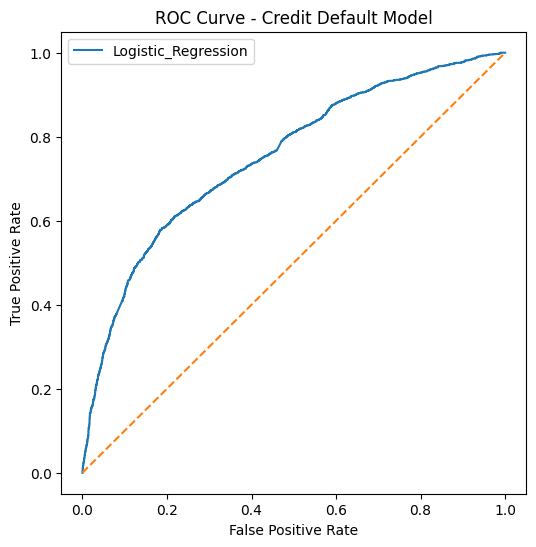

In [ ]:
fpr, tpr, _=roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr, label='Logistic_Regression')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Default Model")
plt.legend()
plt.show()

## Model Evaluation

The logistic regression model demonstrates strong and balanced performance for a real-world credit default prediction task.

Key performance metrics on the test set:

- **ROC-AUC: 0.752**
  - Indicates good discriminatory power between defaulters and non-defaulters
  - The model ranks risky customers meaningfully better than random selection

- **Accuracy: 74%**
  - Reflects overall classification correctness
  - Accuracy alone is not sufficient due to class imbalance and is therefore interpreted alongside recall and precision

- **Recall (Default = 1): 61%**
  - The model correctly identifies a majority of true defaulters
  - This is critical from a risk management perspective, as missing defaulters is more costly than false positives

- **Precision (Default = 1): 44%**
  - Indicates some conservative over-flagging of risk
  - Acceptable in early-stage screening models where recall is prioritized over approval rates

- **Class Imbalance Handling**
  - Class-weighted logistic regression successfully improves default detection
  - Trade-off favors risk capture over approval maximization

Overall, the model achieves a strong balance between interpretability, recall, and ranking power, making it suitable as a baseline credit risk model.

## Feature Importance Analysis

Logistic regression coefficients provide directional insight into how features influence default risk.

Positive coefficients increase default probability  
Negative coefficients reduce default probability

In [ ]:
feature_importance = pd.DataFrame({'Feature': engineered_features,'Coefficient': log_reg.coef_[0]}).sort_values(by='Coefficient', ascending=False)

feature_importance

,Feature,Coefficient
2,number_of_delinquency_months,0.789513
7,payment_std,0.441857
1,Max_Delinquency,0.345203
4,avg_utilization,0.193311
3,delinquency_trend,0.161726
11,high_utilization_flag,0.150098
10,Avg_bill,0.053857
12,chronic_delinquency_flag,0.005129
13,severe_delinquency_flag,-0.018909
9,bill_std,-0.026098


## Interpretation of Risk Drivers

Logistic regression coefficients provide directional insight into how engineered behavioral features influence default probability.

### Strongest Positive Risk Drivers (Increase Default Probability)

- **Number of Delinquency Months**
  - The single strongest predictor of default
  - Repeated delinquency signals persistent financial stress rather than isolated events

- **Payment Volatility (payment_std)**
  - High variability in payments indicates unstable cash flow and inconsistent repayment behavior
  - Customers with irregular payment patterns are significantly more likely to default

- **Maximum Delinquency Severity**
  - Severe past delinquency episodes materially increase future default risk
  - Captures tail-risk behavior not reflected in averages alone

- **Average Credit Utilization**
  - Higher utilization reflects dependency on revolving credit
  - Sustained balance usage reduces repayment flexibility and increases default likelihood

- **Worsening Delinquency Trend**
  - Positive trend values indicate deterioration in recent repayment behavior
  - Trend-based features successfully capture momentum risk beyond static snapshots

### Moderate Risk Signals

- **High Utilization Flag**
  - Binary risk flags complement continuous utilization measures
  - Particularly useful for policy-based decisioning and monitoring thresholds

- **Average Monthly Balance**
  - Larger sustained balances modestly increase default probability through exposure pressure

### Risk-Reducing (Protective) Factors

- **Average Monthly Payment**
  - The strongest negative coefficient
  - Consistent and higher payments materially reduce default risk

- **Average Delinquency**
  - Negative coefficient reflects dominance of recent and maximum delinquency over long-term averages
  - Suggests recent behavior is more predictive than historical smoothing

- **Payment-to-Bill Ratio**
  - Higher ratios indicate disciplined repayment and lower financial stress

### Key Takeaway

Default risk in this portfolio is driven primarily by **behavioral instability and delinquency persistence**, rather than demographic or static exposure variables.  
This aligns closely with real-world credit underwriting logic and validates the feature engineering strategy.


## Final Modeling Summary & Next Steps

### Summary

- A fully interpretable, regulator-friendly logistic regression model was successfully developed
- The model demonstrates strong ranking performance (ROC-AUC ~0.75)
- Behavioral features dominate default prediction, particularly:
  - Delinquency frequency and severity
  - Payment stability
  - Credit utilization dynamics
- The modeling approach prioritizes risk capture while maintaining transparency

### Business Readiness

- Suitable for:
  - Credit pre-screening
  - Risk segmentation
  - Early warning systems
- Coefficients provide explainability for audit and regulatory review
- Model outputs can be directly converted into scorecards or policy rules

### Next Steps

- Threshold optimization based on business cost trade-offs
- Comparison with non-linear models (Decision Trees, Gradient Boosting)
- Probability calibration (PD alignment)
- Stability and population shift analysis

This notebook establishes a strong baseline for production-grade credit risk modeling.
